 # Customer Churn Prediction — Exploratory Data Analysis

**Objective:** Understand which customers are likely to churn from property/telecom-style features.  
**Target variable:** `churn` (`Yes` / `No`)  
**Context:** Messy customer data loaded from CSV for practicing a full EDA workflow end to end (same step pattern as the house-price EDA session).

### How to use this notebook
Work top to bottom. Each numbered step has:
1. A short **why** (purpose of the step)
2. Code that performs the step (fill every `# TODO` cell)
3. Space for insights at the end

| Step | Focus |
|------|--------|
| 1–2 | Load / inspect |
| 3–5 | Missing values, duplicates, dtypes |
| 6–7 | Summaries & outliers |
| 8 | Binning (after outliers) |
| 9–11 | Uni / bi / multivariate visuals |
| 12 | Key findings (markdown) |

**Dataset file:** `customer_churn.csv` (same folder as this notebook).

**Required names for grading:** `df`, `raw_shape`, `missing_df`, `num_cols_with_na`, `cat_cols_with_na`, `df_before_outliers`, `outliers_iqr_mask`, `age_bin`, `corr_matrix`, `multi_corr`, `top_corr_with_churn`

# **Important**:Make sure you use the same variable name mentioned above

## 0. Imports

Import numpy, pandas, matplotlib, seaborn, and display helpers.

In [18]:
# TODO: Write your solution here.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
sns.set_theme(style="whitegrid")

## 1. Load Dataset

### Why this step
EDA starts with data on disk. Load `customer_churn.csv` so the rest of the notebook mirrors a real workflow: read a file, then clean and plot.

### What the code does
1. Reads the CSV with `pd.read_csv` into **`df`**.
2. Prints shape and column names, then shows the first few rows.

In [19]:
# TODO: Write your solution here.
df = pd.read_csv("customer_churn.csv")
raw_shape = df.shape
print("Dataset shape:", raw_shape)
print("\nColumn names:")
print(df.columns.tolist())
display(df.head())

Dataset shape: (518, 12)

Column names:
['customer_id', 'age', 'tenure_months', 'monthly_charges', 'total_charges', 'num_support_tickets', 'contract_type', 'internet_service', 'payment_method', 'gender', 'partner', 'churn']


,customer_id,age,tenure_months,monthly_charges,total_charges,num_support_tickets,contract_type,internet_service,payment_method,gender,partner,churn
0,C10000,19.0,6,84.50,506.79,6,Month-to-month,Fiber optic,Credit card,Female,No,Yes
1,C10001,27.0,56,106.48,5951.56,4,Two year,No,Electronic check,Male,Yes,No
2,C10002,24.0,47,64.30,3449.02,0,One year,Fiber optic,Credit card,Female,No,No
3,C10003,NaN,32,43.28,1335.41,7,One year,Fiber optic,Credit card,Female,No,No
4,C10004,56.0,31,42.14,1266.18,3,One year,Fiber optic,Credit card,Female,No,No


## 2. Inspect the Data

### Why this step
Never clean or model blind. First look at samples and types so you know what each column is and whether missing values already appear.

### What the code does
- `head()` / `tail()`: first and last rows
- `dtypes`: int / float / object
- `info()`: non-null counts and memory

In [20]:
# TODO: Write your solution here.
print("First 5 rows:")
display(df.head())
print("\nLast 5 rows:")
display(df.tail())
print("\nData types:")
print(df.dtypes)
print("\nDataset information:")
df.info()

First 5 rows:


,customer_id,age,tenure_months,monthly_charges,total_charges,num_support_tickets,contract_type,internet_service,payment_method,gender,partner,churn
0,C10000,19.0,6,84.50,506.79,6,Month-to-month,Fiber optic,Credit card,Female,No,Yes
1,C10001,27.0,56,106.48,5951.56,4,Two year,No,Electronic check,Male,Yes,No
2,C10002,24.0,47,64.30,3449.02,0,One year,Fiber optic,Credit card,Female,No,No
3,C10003,NaN,32,43.28,1335.41,7,One year,Fiber optic,Credit card,Female,No,No
4,C10004,56.0,31,42.14,1266.18,3,One year,Fiber optic,Credit card,Female,No,No



Last 5 rows:


,customer_id,age,tenure_months,monthly_charges,total_charges,num_support_tickets,contract_type,internet_service,payment_method,gender,partner,churn
513,C10084,79.0,45,NaN,1324.55,5,Month-to-month,DSL,Electronic check,Female,Yes,Yes
514,C10371,36.0,48,67.95,3486.47,2,Two year,DSL,Mailed check,Male,No,No
515,C10388,44.0,65,96.92,5779.48,6,Month-to-month,Fiber optic,Credit card,Male,Yes,No
516,C10495,52.0,30,67.93,1787.24,7,Month-to-month,DSL,Credit card,Female,Yes,Yes
517,C10030,46.0,32,22.43,765.80,4,One year,DSL,Bank transfer,Female,Yes,No



Data types:
customer_id             object
age                    float64
tenure_months            int64
monthly_charges        float64
total_charges          float64
num_support_tickets      int64
contract_type           object
internet_service        object
payment_method          object
gender                  object
partner                 object
churn                   object
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          518 non-null    object 
 1   age                  489 non-null    float64
 2   tenure_months        518 non-null    int64  
 3   monthly_charges      494 non-null    float64
 4   total_charges        498 non-null    float64
 5   num_support_tickets  518 non-null    int64  
 6   contract_type        502 non-null    object 
 7   internet_service   

## 3. Handle Missing Values

### Why this step
Models and many aggregations fail or become biased when NaNs remain. Find gaps first, then choose a fill strategy that matches each column type.

### 3a. Count nulls
Create **`missing_df`** with columns `Missing` and `Percent`, filtered to columns that have nulls, sorted descending.

In [21]:
# TODO: Write your solution here.
missing_df = (
    df.isna()
      .sum()
      .to_frame("Missing")
      .assign(Percent=lambda x: (x["Missing"] / len(df)) * 100)
      .query("Missing > 0")
      .sort_values("Missing", ascending=False)
)
display(missing_df)


,Missing,Percent
age,29,5.598456
monthly_charges,24,4.633205
total_charges,20,3.861004
contract_type,16,3.088803
internet_service,14,2.702703


### 3b. Inspect numeric missing values (skew → mean vs median)

For skewed numerics prefer **median**; for roughly symmetric prefer **mean**.

Print **`num_cols_with_na`** and **`cat_cols_with_na`**.  
Plot a histogram for a skewed numeric column with nulls (e.g. `monthly_charges`) and print mean / median / mode.

Numeric columns with missing values:
['age', 'monthly_charges', 'total_charges']

Categorical columns with missing values:
['contract_type', 'internet_service']

Histogram for: monthly_charges


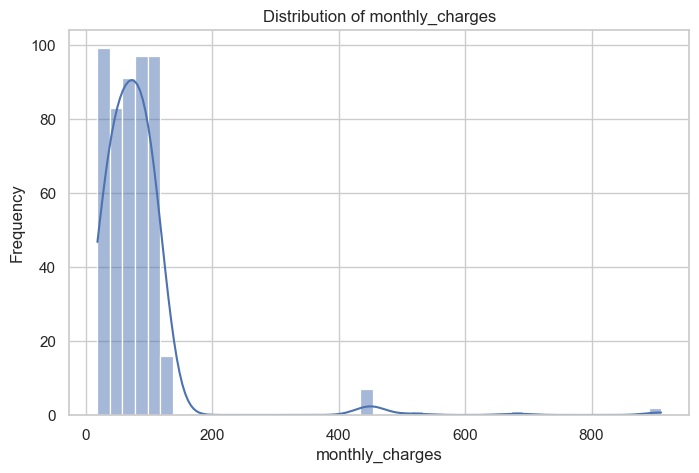

Mean: 80.31449392712551
Median: 70.565
Mode: 450.0


In [22]:
# TODO: Write your solution here.
num_cols_with_na = df.select_dtypes(include=np.number).columns[
    df.select_dtypes(include=np.number).isna().any()
].tolist()

cat_cols_with_na = df.select_dtypes(
    include=["object", "category"]
).columns[
    df.select_dtypes(include=["object", "category"]).isna().any()
].tolist()

print("Numeric columns with missing values:")
print(num_cols_with_na)
print("\nCategorical columns with missing values:")
print(cat_cols_with_na)

skewed_numeric_col = None

for col in num_cols_with_na:
    if abs(df[col].skew()) > 0.5:
        skewed_numeric_col = col
        break

if skewed_numeric_col is not None:
    print(f"\nHistogram for: {skewed_numeric_col}")

    plt.figure(figsize=(8, 5))
    sns.histplot(df[skewed_numeric_col], kde=True)
    plt.title(f"Distribution of {skewed_numeric_col}")
    plt.xlabel(skewed_numeric_col)
    plt.ylabel("Frequency")
    plt.show()

    print("Mean:", df[skewed_numeric_col].mean())
    print("Median:", df[skewed_numeric_col].median())
    print("Mode:", df[skewed_numeric_col].mode().iloc[0])


### 3c. Inspect categorical missing values

For each categorical column with nulls, print the **mode** and **unique values**.

In [23]:
# TODO: Write your solution here.
for col in cat_cols_with_na:
    print(f"\nColumn: {col}")
    print("Mode:", df[col].mode().iloc[0])
    print("Unique values:")
    print(df[col].dropna().unique())



Column: contract_type
Mode: Month-to-month
Unique values:
['Month-to-month' 'Two year' 'One year']

Column: internet_service
Mode: Fiber optic
Unique values:
['Fiber optic' 'No' 'DSL']


### 3d. Fill missing values

Fill in place on **`df`**:
- Numeric: **median** when `|skew| > 0.5`, else **mean**
- Categorical: **mode**
- Any leftover numeric NaNs: `ffill` then `bfill`
- Verify remaining missing count is **0**

In [24]:
# TODO: Write your solution here.
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isna().any():

        if abs(df[col].skew()) > 0.5:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include=["object", "category"]).columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode().iloc[0])

numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = df[numeric_columns].ffill().bfill()
print("Remaining missing values:")
print(df.isna().sum())
print("\nTotal remaining missing values:", df.isna().sum().sum())

Remaining missing values:
customer_id            0
age                    0
tenure_months          0
monthly_charges        0
total_charges          0
num_support_tickets    0
contract_type          0
internet_service       0
payment_method         0
gender                 0
partner                0
churn                  0
dtype: int64

Total remaining missing values: 0


## 4. Duplicate Records

### Why this step
Exact duplicate rows overweight the same customer in averages, correlations, and model training.

### What the code does
Count duplicates with `duplicated()`, then remove them with `drop_duplicates()` and reset the index.

In [25]:
# TODO: Write your solution here.
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 18
Shape after removing duplicates: (500, 12)


### Check remaining nulls

Re-check before type casting. If any null rows remain, drop them.

In [26]:
# TODO: Write your solution here.
remaining_nulls = df.isna().sum()
print("Missing values by column:")
print(remaining_nulls)
if remaining_nulls.sum() > 0:
    df = df.dropna().reset_index(drop=True)
print("\nTotal missing values:", df.isna().sum().sum())
print("Current shape:", df.shape)

Missing values by column:
customer_id            0
age                    0
tenure_months          0
monthly_charges        0
total_charges          0
num_support_tickets    0
contract_type          0
internet_service       0
payment_method         0
gender                 0
partner                0
churn                  0
dtype: int64

Total missing values: 0
Current shape: (500, 12)


## 5. Convert Data Types

### Why this step
Correct types unlock groupbys and integer summaries. Wrong types (e.g. labels as plain object only) make analysis harder.

### What the code does
- Cast label columns to `category`
- Cast whole-number-ish numerics to int where safe
- Create **`churn_flag`** (Yes→1, No→0) for later correlation

Binning comes **after** outlier handling (Step 8).

In [27]:
# TODO: Write your solution here.
categorical_columns = [
    "contract_type",
    "internet_service",
    "payment_method",
    "gender",
    "partner",
    "churn"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

integer_columns = [
    "age",
    "tenure_months",
    "num_support_tickets"
]

for col in integer_columns:
    df[col] = df[col].round().astype(int)

df["churn_flag"] = df["churn"].map({
    "Yes": 1,
    "No": 0
}).astype(int)

print(df.dtypes)
display(df.head())

customer_id              object
age                       int64
tenure_months             int64
monthly_charges         float64
total_charges           float64
num_support_tickets       int64
contract_type          category
internet_service       category
payment_method         category
gender                 category
partner                category
churn                  category
churn_flag                int64
dtype: object


,customer_id,age,tenure_months,monthly_charges,total_charges,num_support_tickets,contract_type,internet_service,payment_method,gender,partner,churn,churn_flag
0,C10000,19,6,84.50,506.79,6,Month-to-month,Fiber optic,Credit card,Female,No,Yes,1
1,C10001,27,56,106.48,5951.56,4,Two year,No,Electronic check,Male,Yes,No,0
2,C10002,24,47,64.30,3449.02,0,One year,Fiber optic,Credit card,Female,No,No,0
3,C10003,48,32,43.28,1335.41,7,One year,Fiber optic,Credit card,Female,No,No,0
4,C10004,56,31,42.14,1266.18,3,One year,Fiber optic,Credit card,Female,No,No,0


## 6. Summary Statistics

### Why this step
Summaries describe center, spread, and range before plotting. Large mean–median gaps hint at skew.

### What the code does
- `describe()` for numerics
- Mean / median / mode table for skewed columns
- Value counts for key categoricals

In [28]:
# TODO: Write your solution here.
print("Summary statistics for numeric columns:")
display(df.select_dtypes(include=np.number).describe())
numeric_columns = df.select_dtypes(include=np.number).columns
skewed_columns = [
    col for col in numeric_columns
    if abs(df[col].skew()) > 0.5
]

if skewed_columns:
    summary_table = pd.DataFrame({
        "Mean": df[skewed_columns].mean(),
        "Median": df[skewed_columns].median(),
        "Mode": df[skewed_columns].mode().iloc[0]
    })

    print("\nMean / Median / Mode for skewed columns:")
    display(summary_table)

categorical_columns = [
    "contract_type",
    "internet_service",
    "payment_method",
    "gender",
    "partner",
    "churn"
]

for col in categorical_columns:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())

Summary statistics for numeric columns:


,age,tenure_months,monthly_charges,total_charges,num_support_tickets,churn_flag
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,47.820000,35.944000,80.293280,2950.670000,3.422000,0.468000
std,17.548433,20.869498,82.003986,4085.726159,2.288754,0.499475
min,18.000000,0.000000,18.130000,25.680000,0.000000,0.000000
25%,33.000000,19.000000,47.005000,995.095000,1.000000,0.000000
50%,48.000000,36.000000,70.565000,1981.050000,3.000000,0.000000
75%,63.000000,54.000000,96.800000,3683.042500,5.000000,1.000000
max,79.000000,72.000000,910.000000,51511.120000,7.000000,1.000000



Mean / Median / Mode for skewed columns:


,Mean,Median,Mode
monthly_charges,80.29328,70.565,70.565
total_charges,2950.67000,1981.050,1981.050



Value counts for contract_type:
contract_type
Month-to-month    300
One year          106
Two year           94
Name: count, dtype: int64

Value counts for internet_service:
internet_service
Fiber optic    240
DSL            157
No             103
Name: count, dtype: int64

Value counts for payment_method:
payment_method
Bank transfer       136
Electronic check    131
Credit card         117
Mailed check        116
Name: count, dtype: int64

Value counts for gender:
gender
Female    279
Male      221
Name: count, dtype: int64

Value counts for partner:
partner
No     271
Yes    229
Name: count, dtype: int64

Value counts for churn:
churn
No     266
Yes    234
Name: count, dtype: int64


## 7. Detect Outliers (IQR & Z-score)

### Why this step
Extreme `monthly_charges` can distort means and correlations. Detect candidates, then **cap (winsorize)** like the house-price notebook (keep rows, reduce extreme pull).

### What the code does
1. Save **`df_before_outliers`**
2. Box plots + IQR / Z-score counts
3. Build **`outliers_iqr_mask`** for `monthly_charges`
4. Cap `monthly_charges` (and `total_charges`) at IQR fences

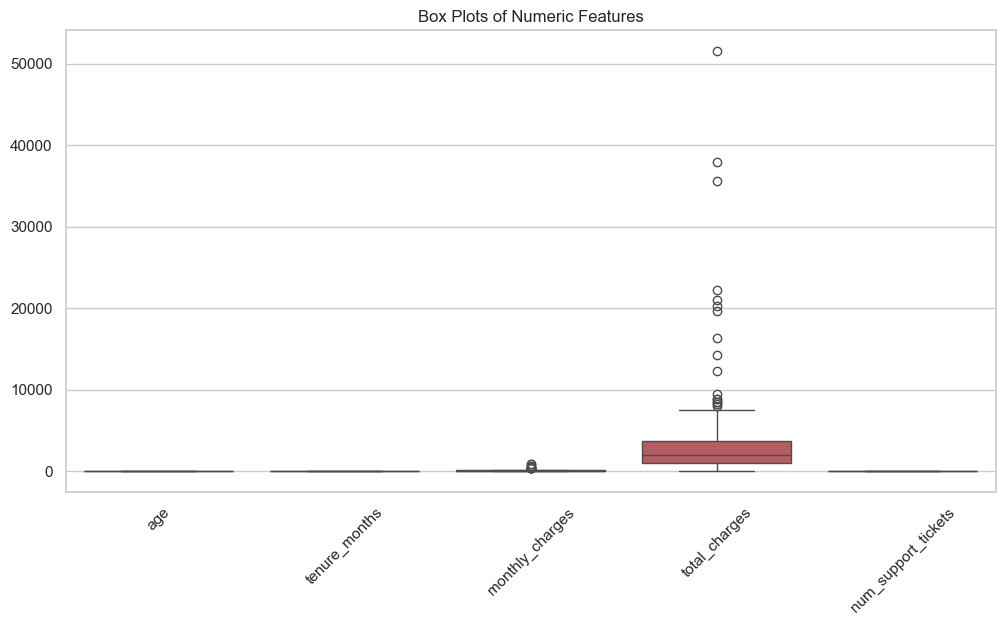

Z-score outlier counts:
age                     0
tenure_months           0
monthly_charges        11
total_charges           8
num_support_tickets     0
dtype: int64

Monthly charges IQR:
Q1: 47.005
Q3: 96.80000000000001
IQR: 49.79500000000001
Lower fence: -27.687500000000007
Upper fence: 171.4925

Number of monthly_charges IQR outliers: 11

Outliers capped successfully.


In [29]:
df_before_outliers = df.copy()

numeric_columns = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "num_support_tickets"
]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_columns])
plt.title("Box Plots of Numeric Features")
plt.xticks(rotation=45)
plt.show()

z_scores = (
    (df[numeric_columns] - df[numeric_columns].mean())
    / df[numeric_columns].std()
).abs()

z_score_counts = (z_scores > 3).sum()

print("Z-score outlier counts:")
print(z_score_counts)

Q1 = df["monthly_charges"].quantile(0.25)
Q3 = df["monthly_charges"].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers_iqr_mask = (
    (df["monthly_charges"] < lower_fence) |
    (df["monthly_charges"] > upper_fence)
)

print("\nMonthly charges IQR:")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

print("\nNumber of monthly_charges IQR outliers:",
      outliers_iqr_mask.sum())

for col in ["monthly_charges", "total_charges"]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower=lower_fence,
        upper=upper_fence
    )

print("\nOutliers capped successfully.")

## 8. Binning

### Why this step
After outliers are handled, turn continuous fields into interpretable categories for group analysis (same idea as engineered features in the house-price EDA session).

### What the code does
Create **`age_bin`** and `tenure_bin`, then show value counts.

In [30]:
# TODO: Write your solution here.
df["age_bin"] = pd.cut(
    df["age"],
    bins=[0, 25, 40, 60, 100],
    labels=["18-25", "26-40", "41-60", "61+"]
)

df["tenure_bin"] = pd.cut(
    df["tenure_months"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

print("Age groups:")
print(df["age_bin"].value_counts().sort_index())

print("\nTenure groups:")
print(df["tenure_bin"].value_counts().sort_index())

Age groups:
age_bin
18-25     66
26-40    116
41-60    179
61+      139
Name: count, dtype: int64

Tenure groups:
tenure_bin
0-12      94
13-24     79
25-48    163
49-72    164
Name: count, dtype: int64


## 9. Univariate Analysis

### Why this step
Study **one variable at a time** first — shape, typical ranges, and category balance — before relating variables to each other.

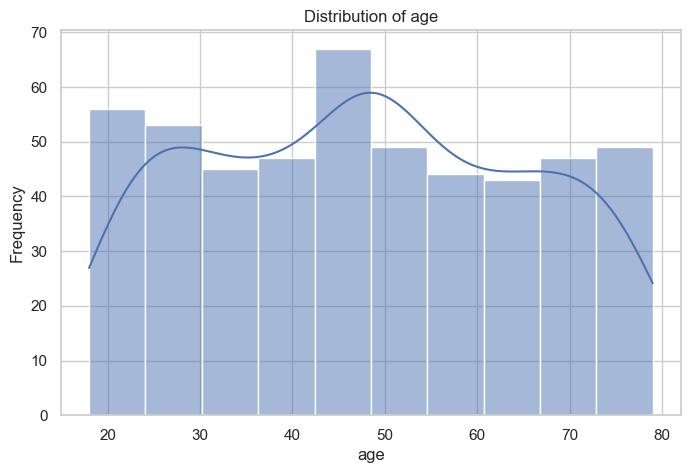

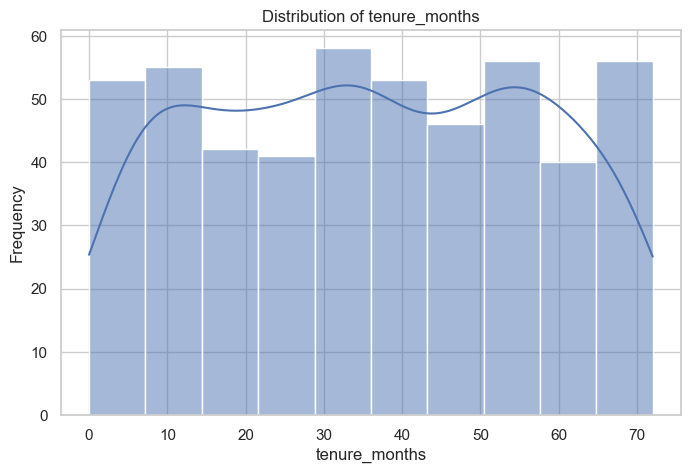

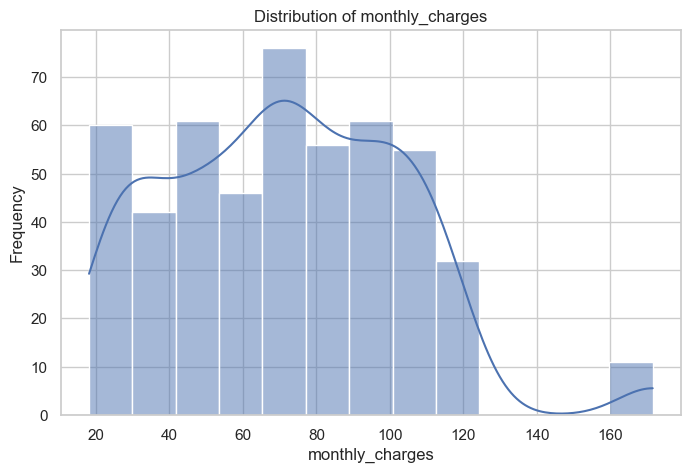

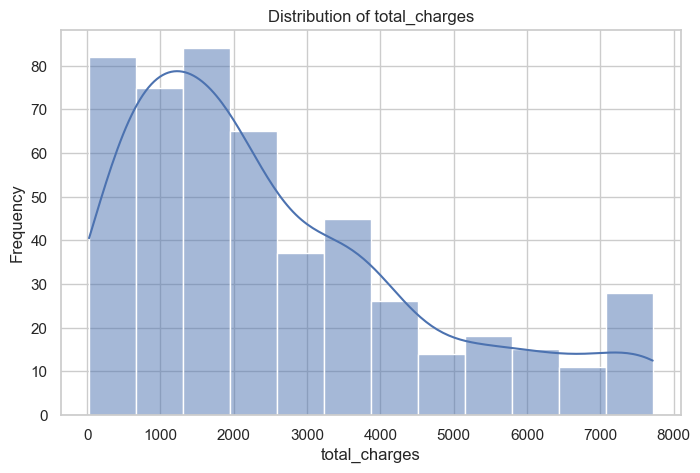

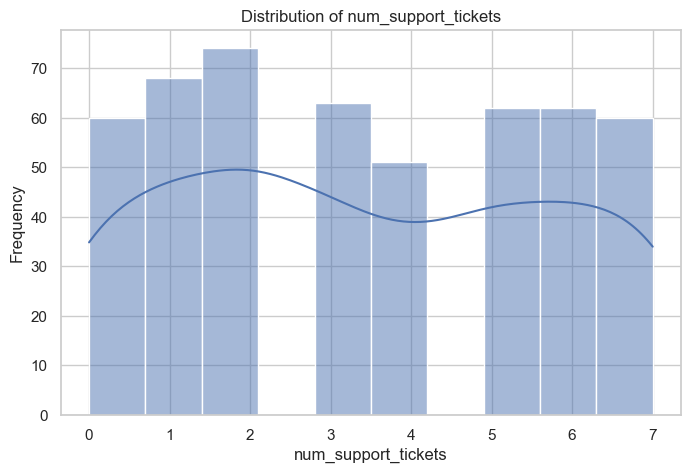

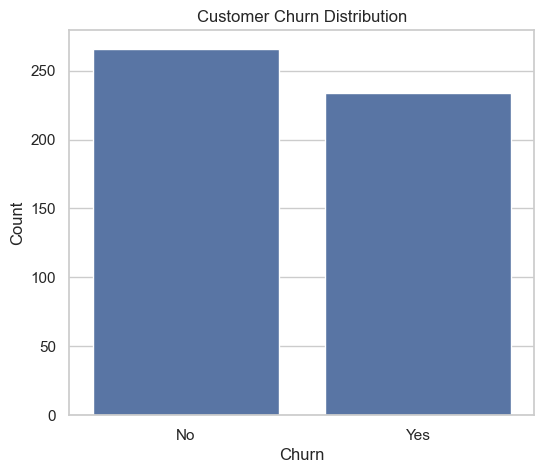

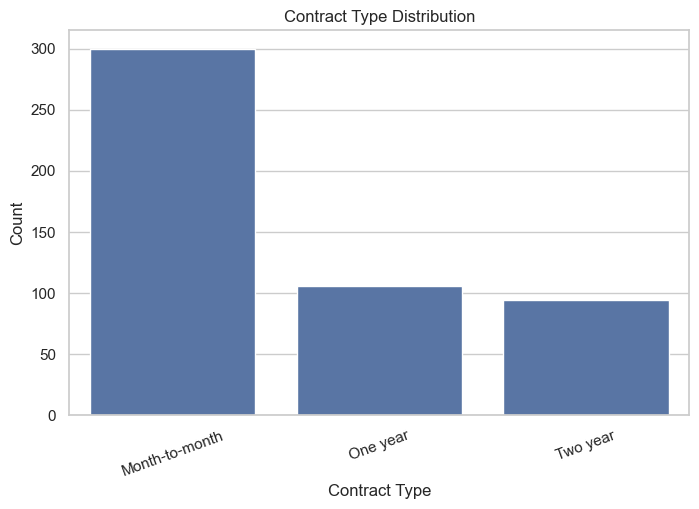

In [33]:
# TODO: Write your solution here.
numeric_columns = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "num_support_tickets"
]
for col in numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="contract_type")
plt.title("Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()


## 10. Bivariate Analysis

### Why this step
Bivariate = relationship between **two** variables — where you find predictors of `churn`.

Split by types:
- **Numerical vs Numerical** — scatter / correlation
- **Numerical vs Categorical** — box / violin / bar
- **Categorical vs Categorical** — crosstab / stacked bar / heatmap

### Numerical vs Numerical

Scatter plots and Pearson correlation with `churn_flag`.

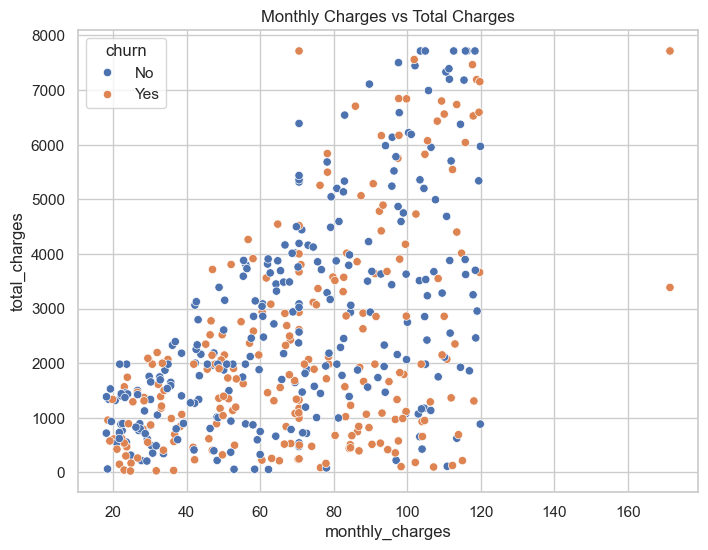

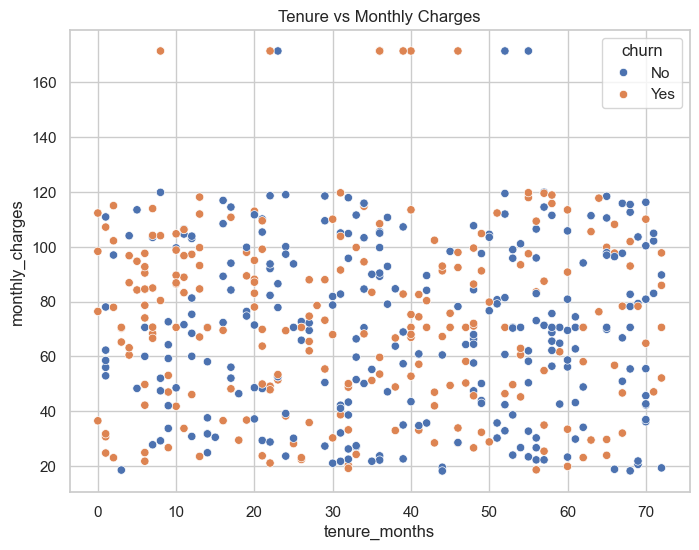

Correlation with churn_flag:


churn_flag             1.000000
num_support_tickets    0.198533
monthly_charges        0.057388
age                    0.047127
total_charges         -0.087216
tenure_months         -0.159550
Name: churn_flag, dtype: float64

In [34]:
# TODO: Write your solution here.
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="monthly_charges",
    y="total_charges",
    hue="churn"
)
plt.title("Monthly Charges vs Total Charges")
plt.show()
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="tenure_months",
    y="monthly_charges",
    hue="churn"
)
plt.title("Tenure vs Monthly Charges")
plt.show()
numeric_for_corr = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "num_support_tickets",
    "churn_flag"
]
corr_with_churn = (
    df[numeric_for_corr]
    .corr()["churn_flag"]
    .sort_values(ascending=False)
)
print("Correlation with churn_flag:")
display(corr_with_churn)


### Numerical vs Categorical

Compare charges / tenure across churn and contract groups.

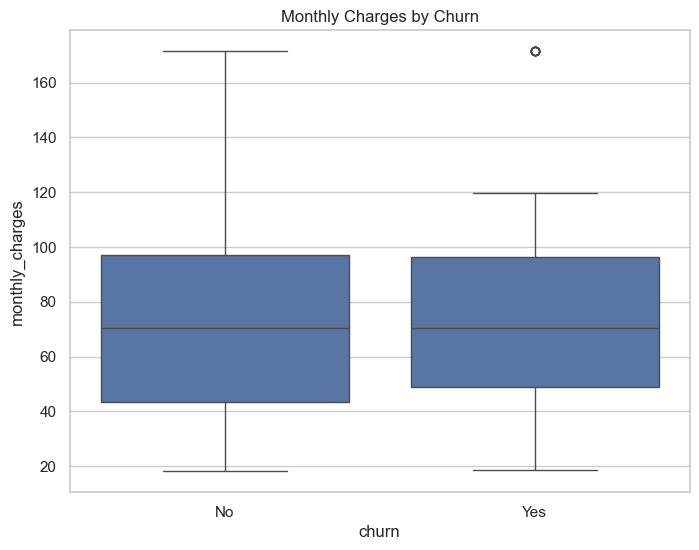

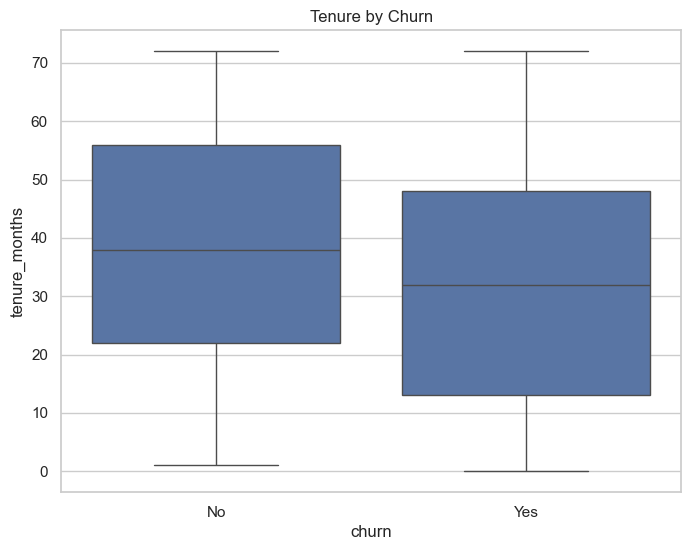

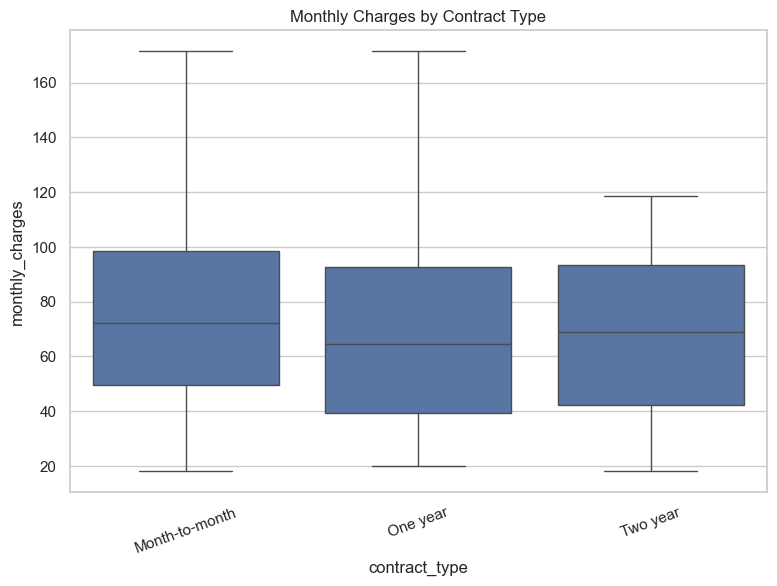

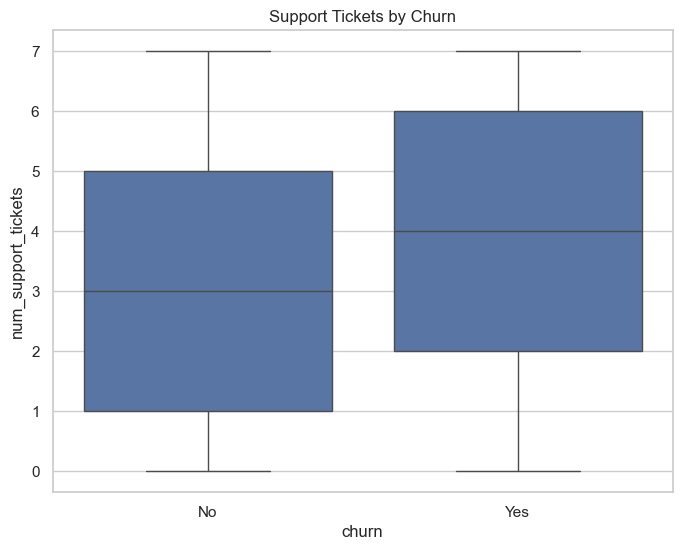

In [35]:
# TODO: Write your solution here.
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="churn",
    y="monthly_charges"
)
plt.title("Monthly Charges by Churn")
plt.show()

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="churn",
    y="tenure_months"
)

plt.title("Tenure by Churn")
plt.show()

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="contract_type",
    y="monthly_charges"
)

plt.title("Monthly Charges by Contract Type")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="churn",
    y="num_support_tickets"
)

plt.title("Support Tickets by Churn")
plt.show()


### Categorical vs Categorical

Crosstabs, stacked bars, and heatmaps for category mixes vs churn.

Contract type vs churn (%):


churn,No,Yes
contract_type,,
Month-to-month,36.333333,63.666667
One year,70.754717,29.245283
Two year,87.234043,12.765957


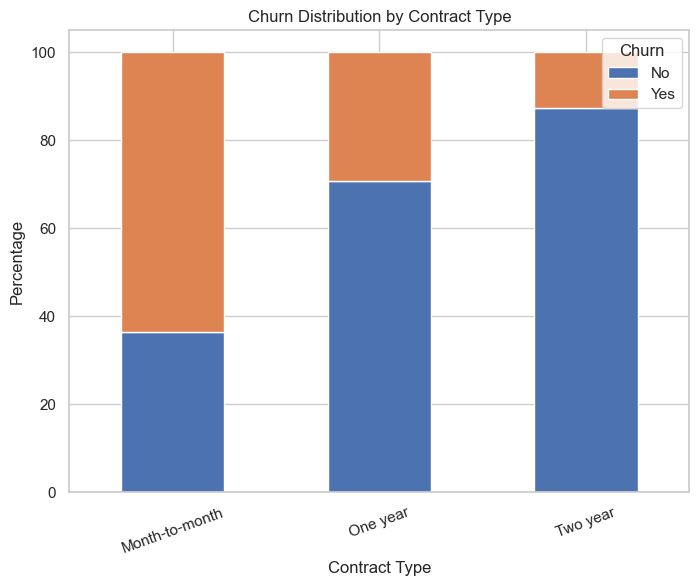

Age group vs churn (%):


churn,No,Yes
age_bin,,
18-25,54.545455,45.454545
26-40,58.620690,41.379310
41-60,51.955307,48.044693
61+,49.640288,50.359712


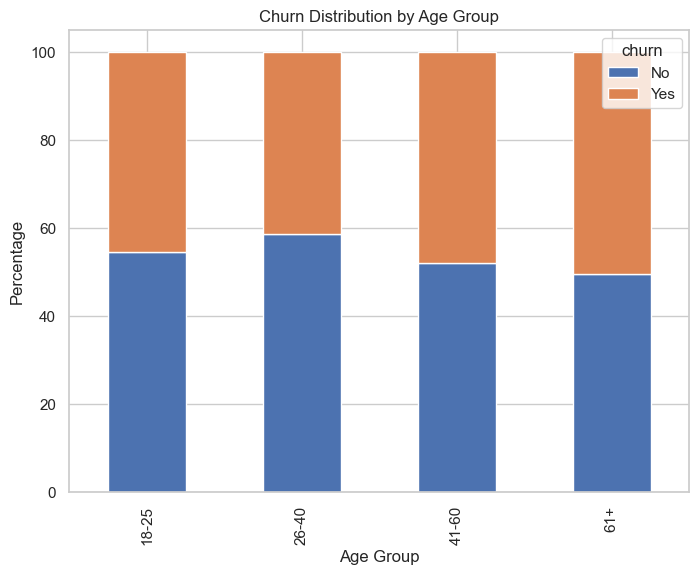

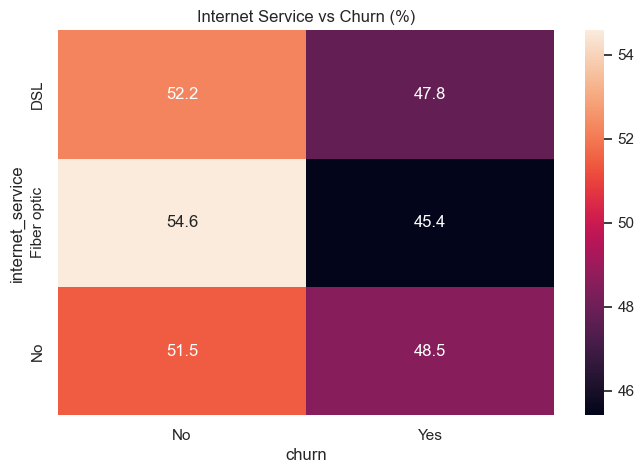

In [36]:
# TODO: Write your solution here.
contract_churn = pd.crosstab(
    df["contract_type"],
    df["churn"],
    normalize="index"
) * 100

print("Contract type vs churn (%):")
display(contract_churn)

contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 6)
)

plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=20)
plt.legend(title="Churn")
plt.show()

age_churn = pd.crosstab(
    df["age_bin"],
    df["churn"],
    normalize="index"
) * 100

print("Age group vs churn (%):")
display(age_churn)

age_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 6)
)

plt.title("Churn Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.show()

internet_churn = pd.crosstab(
    df["internet_service"],
    df["churn"],
    normalize="index"
) * 100

plt.figure(figsize=(8, 5))

sns.heatmap(
    internet_churn,
    annot=True,
    fmt=".1f"
)

plt.title("Internet Service vs Churn (%)")
plt.show()


## 11. Multivariate Analysis

### Why this step
Look at **three or more** signals together — closer to how churn really works (tenure + charges + tickets, etc.).

1. **Heatmap** — many numeric correlations at once (`multi_corr`)
2. **Bubble chart** — scatter with size + color

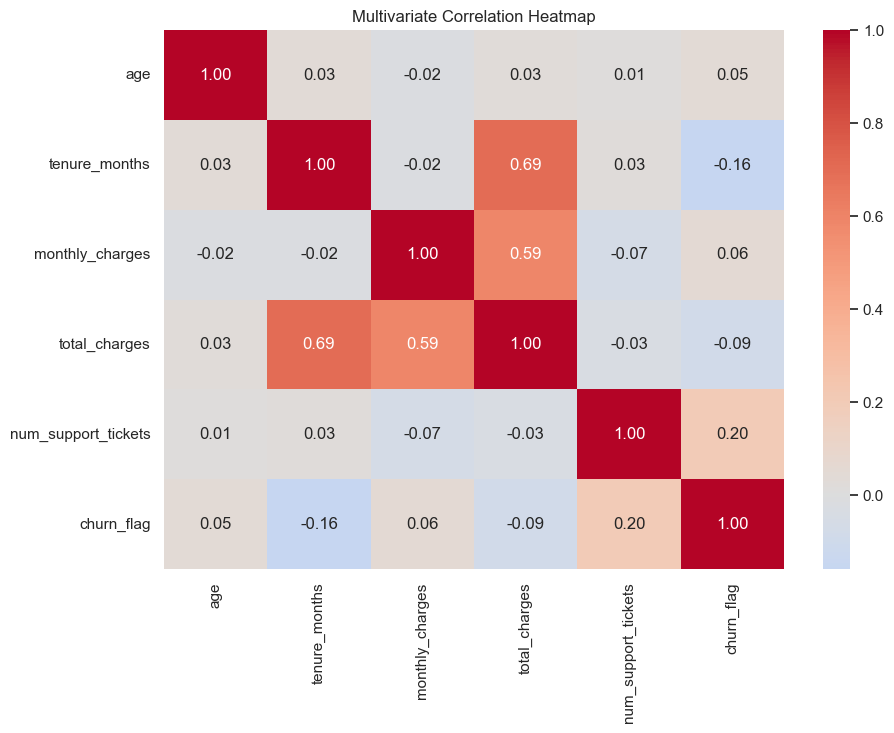

Top correlations with churn_flag:


num_support_tickets    0.198533
tenure_months         -0.159550
total_charges         -0.087216
monthly_charges        0.057388
age                    0.047127
Name: churn_flag, dtype: float64

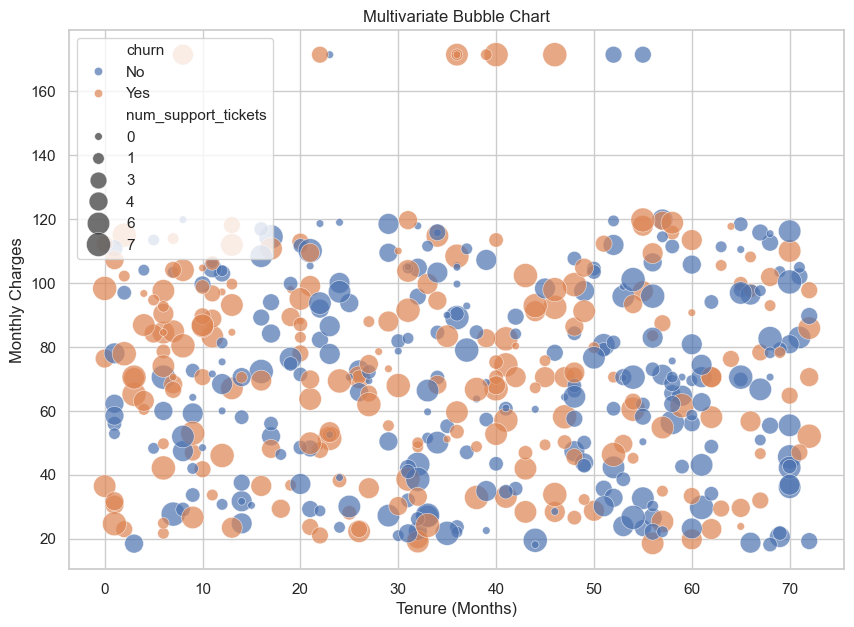

In [37]:
# TODO: Write your solution here.
numeric_columns = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "num_support_tickets",
    "churn_flag"
]

corr_matrix = df[numeric_columns].corr()

multi_corr = corr_matrix

plt.figure(figsize=(10, 7))

sns.heatmap(
    multi_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Multivariate Correlation Heatmap")
plt.show()

top_corr_with_churn = (
    corr_matrix["churn_flag"]
    .drop("churn_flag")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

print("Top correlations with churn_flag:")
display(top_corr_with_churn)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="tenure_months",
    y="monthly_charges",
    size="num_support_tickets",
    hue="churn",
    sizes=(30, 300),
    alpha=0.7
)

plt.title("Multivariate Bubble Chart")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.show()


## 12. KEY FINDINGS — answer in markdown

This is the **final step**. Write 2–4 sentences for each question based on what you observed above.

### Q1. Which numeric features are most correlated with `churn_flag`? What does that imply?
### Q2. After the skew check, did you prefer mean or median for any fills? Why?
### Q3. Which segments (contract, age bin, tickets) look most associated with churn?
### Q4. Why cap outliers instead of deleting rows here?
### Q5. What risk remains before training a churn classifier?

### Your answers

**Q1:** num_support_tickets has the strongest positive relationship with churn,while tenure_months has a negative relationship

**Q2:** Median was used for skewed data because it is less affected by extreme values.

**Q3:** Month-to-month customers and customers with more support tickets have higher churn.

**Q4:** Outliers were capped to reduce their effect without removing useful customer records.

**Q5:** Before building the model, we should check class imbalance, data leakage, correlated features, and train-test splitting.
